# Подготовка датасета
Нижепредставленный код собирает датасет модельки и сохраняетего в /data/dataset.csv.
Его можно расширять добавляя признаки.
TODO: таблица абонементов не задейтсвовано можно от неё признаков добавить

In [151]:
import pandas as pd
import numpy as np

mts_df = pd.read_csv("../data/matches.csv")
zn_df = pd.read_csv("../data/zones.csv")
sl_df = pd.read_csv("../data/sales_daily.csv")

max_days = sl_df.groupby("match_id")["days_before"].transform(np.max)
sl_df["time_progress"] = sl_df["days_before"] / max_days

conditions = [
    sl_df["time_progress"] > 0.75,
    (sl_df["time_progress"] <= 0.75) & (sl_df["time_progress"] > 0.50),  
    (sl_df["time_progress"] <= 0.50) & (sl_df["time_progress"] > 0.25),
    sl_df["time_progress"] <= 0.25,  
]
stages = [1, 2, 3, 4]
sl_df["stage"] = np.select(conditions, stages, default=4)

tickets = sl_df.groupby(["match_id", "zone", "stage"])[["tickets"]].sum().reset_index()
tickets = tickets.sort_values(["match_id", "zone", "stage"])
tickets["tickets"] = tickets.groupby(["match_id", "zone"])["tickets"].cumsum()

stage_zero = tickets.drop_duplicates(subset=["match_id", "zone"]).copy()
stage_zero["stage"] = 0
stage_zero["tickets"] = 0

tickets = pd.concat([tickets, stage_zero], ignore_index=True).sort_values(["match_id", "zone", "stage"])

target_df = tickets[tickets["stage"] == 4][["match_id", "zone", "tickets"]].rename(columns={"tickets": "final_tickets_target"})

tickets = tickets[tickets["stage"] != 4]

zn_df["cap"] = zn_df["seats"] - zn_df["season_tickets"]

df = pd.merge(zn_df, tickets, on=["match_id", "zone"], how="inner")
df = df.merge(target_df, on=["match_id", "zone"], how="left")

df["crowded"] = (df["tickets"] / df["cap"]).replace([np.inf, -np.inf], 0).fillna(0)


df = df.merge(mts_df[['match_id', 'date', 'opponent_khl', 'part']], on='match_id', how='left')

khl_df = pd.read_csv("../data/khl_games.csv")

away_df = khl_df.rename(columns={
    "home": "against_khl", "away": "opponent_khl",
    "home_goals": "against_goals", "away_goals": "opponent_goals"
})
away_df["is_home"] = 0

home_df = khl_df.rename(columns={
    "home": "opponent_khl", "away": "against_khl",
    "home_goals": "opponent_goals", "away_goals": "against_goals"
})
home_df["is_home"] = 1

opponents_df = pd.concat([away_df, home_df], ignore_index=True)
opponents_df['date'] = pd.to_datetime(opponents_df['date'])

opponents_df = opponents_df.sort_values(by=["opponent_khl", "date"]).drop_duplicates(subset=["date", "opponent_khl"]).reset_index(drop=True)

opponents_df["is_win"] = (opponents_df["opponent_goals"] > opponents_df["against_goals"]).astype(int)

groupby_team = opponents_df.groupby('opponent_khl')

opponents_df['rolling_avg_goals'] = (
    groupby_team['opponent_goals']
    .shift(1)
    .groupby(opponents_df['opponent_khl'])
    .expanding()
    .mean()
    .reset_index(level=0, drop=True)
)

opponents_df['wins_last_3_games'] = (
    groupby_team['is_win']
    .shift(1)
    .groupby(opponents_df['opponent_khl'])
    .rolling(window=3, min_periods=1)
    .sum()
    .reset_index(level=0, drop=True)
)

opponents_df['days_since_last_game'] = groupby_team['date'].diff().dt.days

opponents_df['rolling_avg_goals'] = opponents_df['rolling_avg_goals'].fillna(0)
opponents_df['wins_last_3_games'] = opponents_df['wins_last_3_games'].fillna(0)
opponents_df['days_since_last_game'] = opponents_df['days_since_last_game'].fillna(7) 


df["date"] = pd.to_datetime(df["date"])
df["day"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month

df = df.sort_values("date").reset_index(drop=True)
opponents_df = opponents_df.sort_values("date").reset_index(drop=True)

df = pd.merge_asof(
    df, 
    opponents_df[['date', 'opponent_khl', 'rolling_avg_goals', 'wins_last_3_games', 'days_since_last_game', 'is_home']], 
    on='date',          
    by='opponent_khl',      
    direction='backward', 
    allow_exact_matches=False 
)

df['rolling_avg_goals'] = df['rolling_avg_goals'].fillna(0)
df['wins_last_3_games'] = df['wins_last_3_games'].fillna(0)
df['days_since_last_game'] = df['days_since_last_game'].fillna(7)
df['is_home'] = df['is_home'].fillna(1)

history_df = target_df.merge(df[['match_id', 'date']].drop_duplicates(), on='match_id', how='left')
history_df = history_df.sort_values(['zone', 'date'])

history_df['avg_tickets_last_8_games'] = (
    history_df.groupby('zone')['final_tickets_target']
    .shift(1)
    .groupby(history_df['zone'])
    .rolling(window=8, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

history_df['avg_tickets_last_8_games'] = history_df['avg_tickets_last_8_games'].fillna(0)

df = df.merge(history_df[['match_id', 'zone', 'avg_tickets_last_8_games']], on=['match_id', 'zone'], how='left')

df = df[df["part"] == "train"].reset_index(drop=True)

df.sort_values(by=["match_id","zone","stage","date"])

df.to_csv("../data/dataset.csv")

,match_id,zone,seats,season_tickets,cap,stage,tickets,final_tickets_target,crowded,date,opponent_khl,part,day,month,rolling_avg_goals,wins_last_3_games,days_since_last_game,is_home,avg_tickets_last_8_games
0,M001,1,1107,538,569,0,0,451.0,0.000000,2023-09-02,HC Sibir Novosibirsk,train,5,9,0.000000,0.0,7.0,1.0,0.000
19,M001,1,1107,538,569,1,259,451.0,0.455185,2023-09-02,HC Sibir Novosibirsk,train,5,9,0.000000,0.0,7.0,1.0,0.000
20,M001,1,1107,538,569,2,312,451.0,0.548330,2023-09-02,HC Sibir Novosibirsk,train,5,9,0.000000,0.0,7.0,1.0,0.000
21,M001,1,1107,538,569,3,349,451.0,0.613357,2023-09-02,HC Sibir Novosibirsk,train,5,9,0.000000,0.0,7.0,1.0,0.000
22,M001,2,550,126,424,0,0,315.0,0.000000,2023-09-02,HC Sibir Novosibirsk,train,5,9,0.000000,0.0,7.0,1.0,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2698,M085,7,1458,295,1163,3,879,1035.0,0.755804,2025-12-07,HC Spartak Moskva,train,6,12,3.264865,1.0,4.0,0.0,857.375
2699,M085,8,654,165,489,0,0,468.0,0.000000,2025-12-07,HC Spartak Moskva,train,6,12,3.264865,1.0,4.0,0.0,435.250
2700,M085,8,654,165,489,1,161,468.0,0.329243,2025-12-07,HC Spartak Moskva,train,6,12,3.264865,1.0,4.0,0.0,435.250
2695,M085,8,654,165,489,2,293,468.0,0.599182,2025-12-07,HC Spartak Moskva,train,6,12,3.264865,1.0,4.0,0.0,435.250


В данном блоке кода представленна минимальная релизация модели для 

In [147]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import TimeSeriesSplit

features = [
    'zone', 'stage', 'tickets', 'crowded', 'day', 'month', 'cap',
    'opponent_khl', 'rolling_avg_goals', 'wins_last_3_games', 
    'days_since_last_game', 'is_home', 'avg_tickets_last_8_games'
]
cat_features = ['zone', 'opponent_khl']

for col in cat_features:
    df[col] = df[col].astype(str).astype('category')

df = df.sort_values("date").reset_index(drop=True)

unique_matches = df['match_id'].unique()
tscv = TimeSeriesSplit(n_splits=5)

print("--- Старт валидации ---")
for fold, (train_idx, val_idx) in enumerate(tscv.split(unique_matches)):
    train_matches = unique_matches[train_idx]
    val_matches = unique_matches[val_idx]

    X_train = df[df['match_id'].isin(train_matches)][features]
    y_train = df[df['match_id'].isin(train_matches)]['final_tickets_target']
    
    X_val = df[df['match_id'].isin(val_matches)][features]
    y_val = df[df['match_id'].isin(val_matches)]['final_tickets_target']
    
    train_pool = Pool(X_train, y_train, cat_features=cat_features)
    val_pool = Pool(X_val, y_val, cat_features=cat_features)
    
    model = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.1,
        depth=5,
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=42,
        early_stopping_rounds=50,
        verbose=100
    )
    
    model.fit(train_pool, eval_set=val_pool)
    print(f"Fold {fold} завершен.\n")

final_pool = Pool(df[features], df['final_tickets_target'], cat_features=cat_features)
model.fit(final_pool, verbose=0)

df['preds'] = model.predict(final_pool)

df['total_tickets'] = df['preds'].clip(lower=0).round().astype(int)

submission = df[['match_id', 'zone', 'total_tickets']]

submission = submission.loc[df.groupby(['match_id', 'zone'])['stage'].idxmax()]

print("\nПример итогового ответа:")
print(submission.head())


--- Старт валидации ---
0:	learn: 198.1702996	test: 217.7152239	best: 217.7152239 (0)	total: 37ms	remaining: 37s
100:	learn: 38.9116051	test: 149.5988626	best: 149.5368029 (97)	total: 1.15s	remaining: 10.2s
200:	learn: 25.5930283	test: 148.5089507	best: 148.0883056 (175)	total: 1.74s	remaining: 6.92s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 148.0883056
bestIteration = 175

Shrink model to first 176 iterations.
Fold 0 завершен.

0:	learn: 204.2396714	test: 214.7369470	best: 214.7369470 (0)	total: 15.5ms	remaining: 15.4s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 172.9696802
bestIteration = 32

Shrink model to first 33 iterations.
Fold 1 завершен.

0:	learn: 206.8846591	test: 195.4090755	best: 195.4090755 (0)	total: 129ms	remaining: 2m 8s
100:	learn: 71.3964872	test: 110.1497808	best: 109.6877055 (95)	total: 846ms	remaining: 7.53s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 108.3670112
bestIteration = 141

Shrink model

In [137]:
df.head()

,match_id,zone,seats,season_tickets,cap,stage,tickets,final_tickets_target,crowded,date,...,part,day,month,rolling_avg_goals,wins_last_3_games,days_since_last_game,is_home,avg_tickets_last_8_games,preds,total_tickets
0,M001,1,1107,538,569,0,0,451.0,0.000000,2023-09-02,...,train,5,9,NaN,NaN,NaN,NaN,0.0,426.125048,426
1,M001,3,1353,363,990,0,0,646.0,0.000000,2023-09-02,...,train,5,9,NaN,NaN,NaN,NaN,0.0,667.250062,667
2,M001,4,1318,245,1073,1,556,890.0,0.518173,2023-09-02,...,train,5,9,NaN,NaN,NaN,NaN,0.0,883.744759,884
3,M001,4,1318,245,1073,0,0,890.0,0.000000,2023-09-02,...,train,5,9,NaN,NaN,NaN,NaN,0.0,893.146241,893
4,M001,3,1353,363,990,3,555,646.0,0.560606,2023-09-02,...,train,5,9,NaN,NaN,NaN,NaN,0.0,663.609231,664


In [140]:
importance = model.get_feature_importance()

feat_imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("Важность признаков:")
print(feat_imp_df)

Важность признаков:
                     Feature  Importance
0   avg_tickets_last_8_games   24.453826
1                        cap   19.320830
2                       zone   16.207887
3                      month    9.901103
4                    tickets    6.743138
5               opponent_khl    5.667761
6                        day    5.281629
7          rolling_avg_goals    4.214434
8                    crowded    2.222455
9                      stage    2.192776
10      days_since_last_game    1.864475
11                   is_home    1.035282
12         wins_last_3_games    0.894404


In [ ]:
Минимальный подбор гиперпараметров(желательно дополнить более широким подбором с жадными алгоритмами чтоб точно все валидировалось)

In [145]:
param_grid = {
    'depth':[1,3,5,10],
    'learning_rate': [0.03, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5]
}

model_search = CatBoostRegressor(
    iterations=500,
    loss_function='RMSE',
    random_seed=42,
    verbose=0
)

grid_search_result = model_search.grid_search(
    param_grid,
    X=final_pool,
    plot=False
)

print("Лучшие параметры:", grid_search_result['params'])



bestTest = 120.5726377
bestIteration = 499

0:	loss: 120.5726377	best: 120.5726377 (0)	total: 1.64s	remaining: 57.3s

bestTest = 117.1234747
bestIteration = 498

1:	loss: 117.1234747	best: 117.1234747 (1)	total: 2.96s	remaining: 50.3s

bestTest = 112.5419499
bestIteration = 497

2:	loss: 112.5419499	best: 112.5419499 (2)	total: 4.23s	remaining: 46.6s

bestTest = 120.7407763
bestIteration = 499

3:	loss: 120.7407763	best: 112.5419499 (2)	total: 5.98s	remaining: 47.9s

bestTest = 117.2081828
bestIteration = 499

4:	loss: 117.2081828	best: 112.5419499 (2)	total: 7.15s	remaining: 44.3s

bestTest = 113.2317329
bestIteration = 499

5:	loss: 113.2317329	best: 112.5419499 (2)	total: 8.23s	remaining: 41.1s

bestTest = 120.8755016
bestIteration = 499

6:	loss: 120.8755016	best: 112.5419499 (2)	total: 9.22s	remaining: 38.2s

bestTest = 117.1031981
bestIteration = 499

7:	loss: 117.1031981	best: 112.5419499 (2)	total: 10.4s	remaining: 36.2s

bestTest = 112.7465852
bestIteration = 499

8:	loss: 11

Не смог выделить валидационные данные из обученной модельки, с CatBoost по этой части не работал, надо будет разобратся как

Предупреждение: Валидационный пул не найден в истории обучения. Выведен только Train.


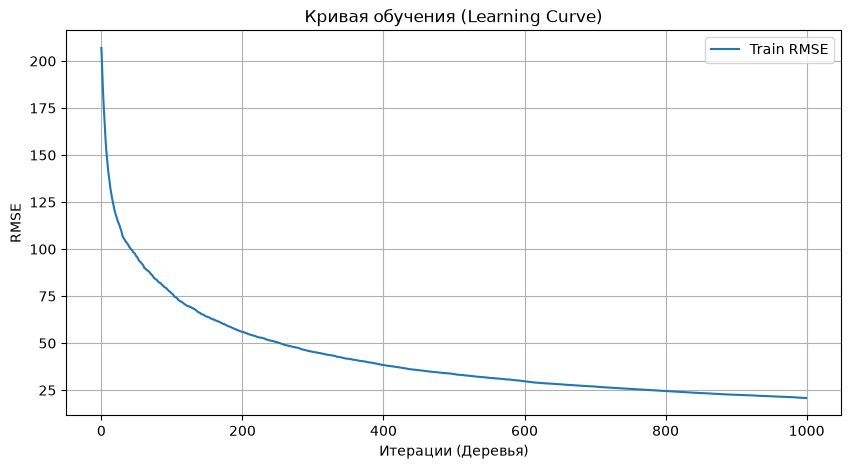

In [148]:
import matplotlib.pyplot as plt

eval_metrics = model.get_evals_result()

train_rmse = eval_metrics['learn']['RMSE']

val_key = [k for k in eval_metrics.keys() if 'validation' in k]

# Строим график
plt.figure(figsize=(10, 5))
plt.plot(train_rmse, label='Train RMSE')

if val_key:
    val_rmse = eval_metrics[val_key[0]]['RMSE']
    plt.plot(val_rmse, label='Validation RMSE')
else:
    print("Предупреждение: Валидационный пул не найден в истории обучения. Выведен только Train.")

plt.xlabel('Итерации (Деревья)')
plt.ylabel('RMSE')
plt.title('Кривая обучения (Learning Curve)')
plt.legend()
plt.grid(True)
plt.show()